# Chemical reaction networks


<div class="note"><span class="note-t">In brief</span>
<p>We map molecule counts onto a continuous-time Markov chain carrying a single token, one occupied bit hopping between count configurations, which lets us run two mass-action reactions in Torx. Irreversible combustion runs toward completion, while reversible binding relaxes to mass-action equilibrium. In both cases we check Torx's split-step approximation against two independent references: the exact matrix exponential and an event-driven Gillespie simulation.</p>
</div>


In this tutorial we run two mass-action reaction networks in Torx and check the result against two independent references.

A chemical reaction network is a continuous-time Markov chain on molecule counts. The state records how many molecules of each species are present, and each reaction event moves that state by a fixed amount. The rate attached to a reaction is its **propensity**, the probability per unit time that this reaction is the next one to fire, and under mass action the propensity counts how many distinct groups of reactant molecules are currently available to react.

We run two networks with deliberately different long-run behaviour. The irreversible water reaction $2\,\mathrm{H_2} + \mathrm{O_2} \to 2\,\mathrm{H_2O}$ fires in a single direction until a reactant is exhausted, so its counts run toward completion. The reversible binding $\mathrm{A} + \mathrm{B} \rightleftharpoons \mathrm{C}$ runs forward and backward at once, so its counts settle into a mass-action equilibrium instead.

Neither network fits a single hopping excitation directly, because a reaction like $2\,\mathrm{H_2} + \mathrm{O_2} \to 2\,\mathrm{H_2O}$ has two features such an excitation can't express. It consumes and produces several molecules at once (stoichiometry), and its rate is nonlinear in the counts (mass action, $a = c\,\binom{n_{\mathrm{H_2}}}{2}\,n_{\mathrm{O_2}}$).

The key step is therefore to enumerate the reachable **count configurations** and treat each one as a state in its own right. Each reaction event then moves the whole system from one configuration to another, and the nonlinear propensity becomes that edge's rate. What's left is a single token, one occupied bit hopping between one-hot configurations, walking on a directed configuration graph, so one `PJUMP` per edge applies, as in a [graph random walk](02_random_walks_on_graphs.ipynb). Sequentially applying those edge kernels approximates the global CTMC evolution.

Two references keep that approximation honest. The matrix exponential $e^{Q t}$ solves the configuration chain exactly, and a Gillespie simulation, an exact event-driven simulation that samples which reaction fires next and when, samples the raw molecule counts without ever seeing the configuration graph.

We assume basic familiarity with continuous-time Markov chains and JAX. The code uses Torx, JAX, NumPy, and SciPy. By the end, you'll be able to:

- enumerate the reachable molecule-count configurations of a reaction network,
- map each reaction's nonlinear mass-action propensity onto a `PJUMP` edge rate, and
- compare the Torx operator-splitting approximation with the exact CTMC ($e^{Q t}$) and a Gillespie simulation.


## Setup

We configure the helper path, the shared plotting style, and the `savefig` utility here so that the later cells can stay focused on the reaction networks themselves.

<details class="tx-disclosure"><summary>What runs where?</summary><ul><li>Torx builds and samples the sequential `PJUMP` circuits.</li><li>Notebook code builds configuration graphs, references, and checks.</li><li>Reaction plots live in <code>examples/helpers/_nb05_crn.py</code>.</li></ul></details>


In [1]:
from pathlib import Path
import sys
from math import comb, exp, log


In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import expm

from torx.psc import DiscretePCircuit, PJUMP, BranchingSimulator



In [3]:
ROOT = Path.cwd()
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
HELPER_DIR = ROOT / "helpers"
sys.path.insert(0, str(HELPER_DIR))



In [4]:
from jax.scipy.special import logit
from _notebook_paths import figure_dir
from _nb05_crn import plot_species_dynamics
from _notebook_style import (
    apply_notebook_style,
    make_savefig,
    EXACT_COLOR,
    TORX_COLOR,
    EXTROPIC_GOLD,
)

In [5]:
FIGURE_DIR = figure_dir(ROOT)
SEED = 0
apply_notebook_style()
savefig = make_savefig(FIGURE_DIR)




Before any chemistry appears, we need the one number that turns a reaction rate into a Torx gate parameter. For one isolated CTMC edge with rate $r$, the transition probability over a slice of length `dt` is exactly $1 - e^{-r\,dt}$, so the `pjump_prob` function below computes that probability and `PJUMP` reads it through a logit.

Each edge kernel is exact on its own, but neighbouring edges share configurations, which means applying them one after another is a [Lie-Trotter operator splitting](https://doi.org/10.1090/S0002-9939-1959-0108732-6) of the global generator: we replace one joint update with an ordered product of single-edge updates. The product therefore approximates $e^{Q\,dt}$ rather than reproducing it, and the approximation improves as `dt` decreases.


In [6]:
def pjump_prob(rate, dt):
    # Exact local CTMC kernel for one directed edge over one slice.
    return 1.0 - exp(-rate * dt)

## The reaction and its configuration space

We start with the irreversible water reaction, because its configuration space is small enough to print in full and read. Starting from four $\mathrm{H_2}$ and two $\mathrm{O_2}$, the single reaction can fire until either reactant runs out, so the reachable configurations form a short chain rather than a branching graph. Along that chain the mass-action propensity drops sharply as $\mathrm{H_2}$ is consumed, and carrying that drop faithfully is the whole point of the encoding.


In [7]:
H2, O2, H2O = 0, 1, 2
species = ["H2", "O2", "H2O"]
# reaction: 2 H2 + O2 -> 2 H2O, with mass-action rate constant c
reactants = {H2: 2, O2: 1}
products = {H2O: 2}
c = 0.10
initial = (4, 2, 0)




Three small functions supply everything the encoding needs: the mass-action propensity of a configuration, the state update when the reaction fires, and a search that collects every reachable configuration.


In [8]:
def propensity(state):
    a = c
    for s, nu in reactants.items():
        a *= comb(int(state[s]), nu)
    return a




In [9]:
def apply_reaction(state):
    """Return the configuration after one firing of the reaction."""
    out = list(state)
    for s, nu in reactants.items():
        out[s] -= nu
    for s, nu in products.items():
        out[s] += nu
    return tuple(out)




In [10]:
def reachable(initial):
    """Enumerate every configuration reachable from `initial` by repeated firings."""
    seen, frontier = {initial}, [initial]
    while frontier:
        s = frontier.pop()
        if all(s[k] >= nu for k, nu in reactants.items()):
            nxt = apply_reaction(s)
            if nxt not in seen:
                seen.add(nxt); frontier.append(nxt)
    return sorted(seen)




In [11]:
configs = reachable(initial)
index = {c2: i for i, c2 in enumerate(configs)}
config_edges = [
    (index[s], index[apply_reaction(s)], propensity(s))
    for s in configs if all(s[k] >= nu for k, nu in reactants.items())
]
print("reachable configurations:", configs)
for i, j, rate in config_edges:
    print(f"  {configs[i]} -> {configs[j]}   propensity = {rate:.3f}")

reachable configurations: [(0, 0, 4), (2, 1, 2), (4, 2, 0)]
  (2, 1, 2) -> (0, 0, 4)   propensity = 0.100
  (4, 2, 0) -> (2, 1, 2)   propensity = 1.200


<div class="note"><span class="note-t">Mass-action rates</span>
<p>From the initial configuration $(4, 2, 0)$ the reaction fires at $c\,\binom{4}{2}\binom{2}{1} = 1.2$. After a single firing, from $(2, 1, 2)$, the propensity drops to $c\,\binom{2}{2}\binom{1}{1} = 0.1$. That twelve-fold drop across one event is the nonlinearity that separates a reaction network from a plain random walk, where every edge rate is fixed in advance.</p>
</div>


## Dynamics: Torx against two references

With the configuration graph in hand, we can ask whether the encoding reproduces the reaction's dynamics. To answer that we compute three trajectories of the expected molecule counts, each a different way. The exact $e^{Qt}p_0$ on the configuration generator is what the encoding has to match, since it solves the same chain with no splitting and no sampling. A [Gillespie (1977)](https://doi.org/10.1021/j100540a008) simulation, an exact event-driven simulation that samples which reaction fires next and when, runs on the raw counts and never touches the configuration graph, so it serves as an independent reference sampler that would expose a mistake in the enumeration itself. The Torx split-step sample mean from snapshot circuits is the quantity under test, and it carries both split-step error and sampling error.

<details class="tx-disclosure"><summary>Term: Gillespie stochastic simulation algorithm (SSA)</summary><p>The <a href="https://doi.org/10.1021/j100540a008">Gillespie SSA</a> represents reactions as competing stochastic clocks. At each step, draw an exponential waiting time using the total propensity, choose a reaction in proportion to its propensity, update the counts, and repeat.</p></details>


In [12]:
def ctmc_reference(n_configs, config_edges, p0, times):
    Q = np.zeros((n_configs, n_configs))
    for i, j, rate in config_edges:
        Q[j, i] += rate
        Q[i, i] -= rate
    return np.stack([expm(Q * t) @ p0 for t in times]), Q


def split_step_distribution(config_edges, p0, horizon, n_steps):
    """Apply the directed-edge CTMC kernels sequentially for `n_steps`."""
    distribution = np.array(p0, dtype=float, copy=True)
    step_dt = horizon / n_steps
    for _ in range(n_steps):
        for source, target, rate in config_edges:
            transferred = distribution[source] * pjump_prob(rate, step_dt)
            distribution[source] -= transferred
            distribution[target] += transferred
    return distribution


In [13]:
def to_counts(dist, configs):
    """Project a distribution over configurations onto expected molecule counts."""
    return dist @ np.array(configs, dtype=float)




In [14]:
def gillespie_mean(times, n_traj, rng):
    """Average `n_traj` Gillespie trajectories on the fixed time grid `times`."""
    acc = np.zeros((len(times), len(species)))
    for _ in range(n_traj):
        state = np.array(initial); t = 0.0; idx = 0; rec = np.zeros((len(times), len(species)))
        while idx < len(times):
            a = propensity(state) if all(state[k] >= nu for k, nu in reactants.items()) else 0.0
            if a <= 0:
                while idx < len(times): rec[idx] = state; idx += 1
                break
            tau = rng.exponential(1.0 / a)
            while idx < len(times) and times[idx] < t + tau: rec[idx] = state; idx += 1
            state = np.array(apply_reaction(tuple(state))); t += tau
        acc += rec
    return acc / n_traj




We evaluate both references on a shared time grid, starting with all the probability on the initial configuration so that every method begins from the same state. The same cell also refines the split-step calculation once, halving `dt` to see whether the deterministic residual shrinks with it.


In [15]:
T, N = 12.0, 240
dt = T / N
times = np.linspace(0.0, T, N + 1)
p0 = np.zeros(len(configs)); p0[index[initial]] = 1.0

ref_dist, Q = ctmc_reference(len(configs), config_edges, p0, times)
ref_counts = to_counts(ref_dist, configs)
gillespie_counts = gillespie_mean(times, 20_000, np.random.default_rng(SEED))

split_coarse = split_step_distribution(config_edges, p0, T, N)
split_fine = split_step_distribution(config_edges, p0, T, 2 * N)
split_error_coarse = float(np.max(np.abs(split_coarse - ref_dist[-1])))
split_error_fine = float(np.max(np.abs(split_fine - ref_dist[-1])))
assert split_error_fine < split_error_coarse
print(
    f"split-step max residual at T={T:g}: dt={dt:g} gives {split_error_coarse:.6f}, "
    f"dt={dt / 2:g} gives {split_error_fine:.6f}"
)


split-step max residual at T=12: dt=0.05 gives 0.000830, dt=0.025 gives 0.000413


Now we build the Torx circuit itself. Each slice applies one `PJUMP` per configuration edge, with parameter $\mathrm{logit}(1 - e^{-r\,dt})$ for rate $r$, and because those kernels are applied in sequence rather than jointly, their ordered product is the split-step approximation and not the exact global CTMC kernel. The refinement check just printed is what tells us the resulting gap is a timestep artifact rather than an error in the encoding: halving `dt` from $0.05$ to $0.025$ cut the deterministic residual at $T = 12$ from $0.000830$ to $0.000413$. Sampling these circuits at selected repetition counts gives the Torx count estimates below.


In [16]:
gates = [PJUMP([i, j]) for i, j, r in config_edges]
thetas = [jnp.array([logit(pjump_prob(r, dt))]) for i, j, r in config_edges]
init_bits = jnp.zeros(len(configs), dtype=jnp.int32).at[index[initial]].set(1)
snapshot_reps = np.arange(0, N + 1, 24, dtype=int)
snapshot_times = snapshot_reps * dt
sim = BranchingSimulator(num_samples=20_000)
keys = jax.random.split(jax.random.key(SEED), len(snapshot_reps))

torx_dist = []
for reps, key in zip(snapshot_reps, keys):
    if reps == 0:
        torx_dist.append(np.asarray(init_bits, dtype=float))
        continue
    compiled = sim.build_circuit(DiscretePCircuit(gates, reps=int(reps)), thetas)
    torx_dist.append(np.asarray(sim.sample(compiled, init_bits, key)).mean(axis=0))
torx_counts = to_counts(np.stack(torx_dist), configs)
print("evaluated", len(snapshot_reps), "snapshots")

evaluated 11 snapshots


We plot the expected counts from all three methods together, with a residual panel underneath, because the disagreements are far too small to see in the trajectories alone.


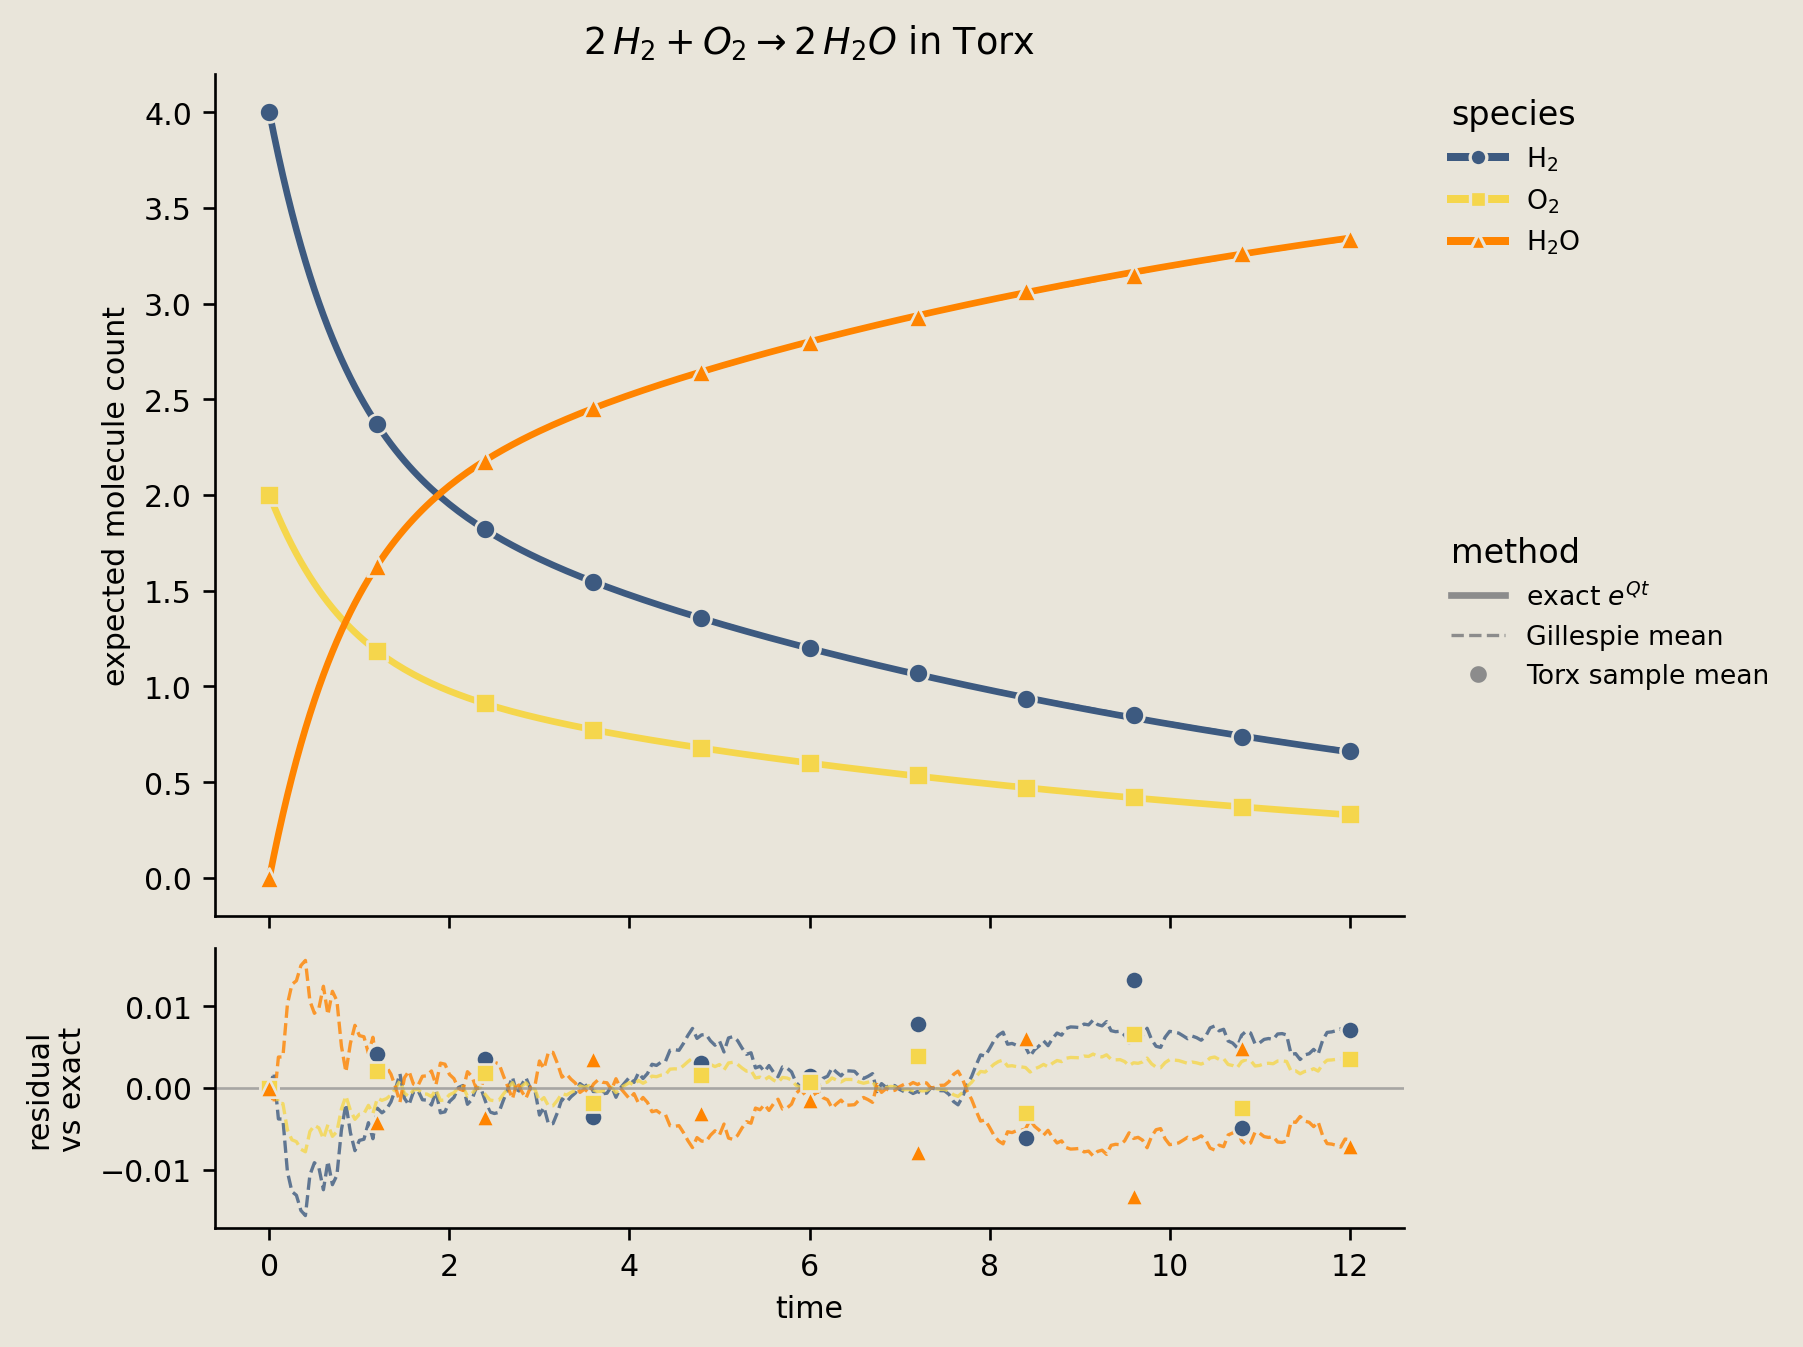

In [17]:
series = [
    (r"$\mathrm{H_2}$", H2, EXACT_COLOR, "o"),
    (r"$\mathrm{O_2}$", O2, EXTROPIC_GOLD, "s"),
    (r"$\mathrm{H_2O}$", H2O, TORX_COLOR, "^"),
]
fig = plot_species_dynamics(
    r"$2\,H_2 + O_2 \rightarrow 2\,H_2O$ in Torx",
    times, ref_counts, gillespie_counts, snapshot_times, torx_counts, series,
)
savefig(fig, "05_crn_dynamics")


All three count trajectories sit on top of one another at this scale, so the residual panel is where the differences become legible. There the dashed Gillespie means fluctuate around the exact solution because they carry sampling error only, while the shaped Torx markers carry both sampling error and split-step error at each snapshot. The chemistry is visible in the upper panel: $\mathrm{H_2}$ and $\mathrm{O_2}$ are consumed as $\mathrm{H_2O}$ builds up, and the falling propensity slows the reaction as it approaches absorption.


## Verification

If the configuration-graph encoding is faithful, two things have to hold: every edge must respect the chemistry it stands for, and every method that solves the same chain must agree at the sampled times, and the next cell tests both claims in the three passes described below.

The first check tests the edges. We recompute the H and O atom totals at both endpoints of every reaction edge and require them to be equal, so a stoichiometry mistake in the enumeration fails the assertion outright instead of hiding as a small numerical drift.

The second check tests Torx. We compare the Torx snapshot counts against the exact matrix exponential at the same times and require the largest absolute deviation to stay under $0.05$, which bounds the combined split-step and sampling error.

The third check tests the reference sampler the same way. We compare the Gillespie means against the exact matrix exponential under the same $0.05$ bound, so agreement here confirms that the raw-count simulation and the configuration-graph solution are describing one reaction rather than two.


In [18]:
atoms = {"H": np.array([2, 0, 2]), "O": np.array([0, 2, 1])}
for i, j, _ in config_edges:
    for w in atoms.values():
        assert w @ np.array(configs[i]) == w @ np.array(configs[j])

torx_vs_exact = float(np.max(np.abs(torx_counts - ref_counts[snapshot_reps])))
gil_vs_exact = float(np.max(np.abs(gillespie_counts[snapshot_reps] - ref_counts[snapshot_reps])))
assert torx_vs_exact < 0.05 and gil_vs_exact < 0.05
print(f"atom conservation (H, O)       : OK")
print(f"max |Torx - exact|             : {torx_vs_exact:.4f}  (< 0.05)")
print(f"max |Gillespie - exact|        : {gil_vs_exact:.4f}  (< 0.05)")
print("all checks passed")

atom conservation (H, O)       : OK
max |Torx - exact|             : 0.0132  (< 0.05)
max |Gillespie - exact|        : 0.0065  (< 0.05)
all checks passed


## A reversible reaction: binding equilibrium

The second network puts the same encoding to work on dynamics that never stop. The water reaction above is irreversible, firing in one direction until a reactant runs out, so its molecule counts run to completion. Binding behaves differently, and the reaction $\mathrm{A} + \mathrm{B} \rightleftharpoons \mathrm{C}$ shows why, because it has a forward step $\mathrm{A} + \mathrm{B} \to \mathrm{C}$ with propensity $k_f\,n_{\mathrm{A}}\,n_{\mathrm{B}}$ and a reverse step $\mathrm{C} \to \mathrm{A} + \mathrm{B}$ with propensity $k_r\,n_{\mathrm{C}}$, and because both directions stay active the network never absorbs. It relaxes instead to a stochastic mass-action equilibrium, meaning a steady distribution in which the ensemble forward and reverse fluxes balance. The split-step construction is unchanged, except that the configuration graph now carries edges in both directions.


We define two reactions now, forward and reverse, each with its own rate constant, so the propensity and update helpers take the reaction as an argument instead of reading a single global one. That generalizes the single-reaction versions from the water network without changing what they compute.


In [19]:
A, B, C = 0, 1, 2
species = ["A", "B", "C"]
# two reactions: forward binding A + B -> C (kf), reverse C -> A + B (kr)
kf, kr = 0.18, 0.55
reactions = [
    ({A: 1, B: 1}, {C: 1}, kf),   # forward:  a = kf * nA * nB
    ({C: 1}, {A: 1, B: 1}, kr),   # reverse:  a = kr * nC
]
initial = (4, 4, 0)




In [20]:
def propensity(state, reac, rate):
    """Mass-action propensity of reaction `reac` at `state`."""
    a = rate
    for s, nu in reac.items():
        a *= comb(int(state[s]), nu)
    return a




In [21]:
def apply_reaction(state, reac, prod):
    """Return the configuration after one firing of the (`reac`, `prod`) reaction."""
    out = list(state)
    for s, nu in reac.items():
        out[s] -= nu
    for s, nu in prod.items():
        out[s] += nu
    return tuple(out)




In [22]:
def reachable(initial):
    """Enumerate every configuration reachable from `initial` under all reactions."""
    seen, frontier = {initial}, [initial]
    while frontier:
        s = frontier.pop()
        for reac, prod, rate in reactions:
            if all(s[k] >= nu for k, nu in reac.items()):
                nxt = apply_reaction(s, reac, prod)
                if nxt not in seen:
                    seen.add(nxt); frontier.append(nxt)
    return sorted(seen)




Enumeration follows both directions from here, which means the search reaches each configuration from either side and the configuration graph ends up carrying a forward and a reverse edge between every adjacent pair.


In [23]:
configs_b = reachable(initial)
index_b = {c2: i for i, c2 in enumerate(configs_b)}
edges_b = [
    (index_b[s], index_b[apply_reaction(s, reac, prod)], propensity(s, reac, rate))
    for s in configs_b for reac, prod, rate in reactions
    if all(s[k] >= nu for k, nu in reac.items())
]
print("reachable configurations:", configs_b)
for i, j, rate in edges_b:
    print(f"  {configs_b[i]} -> {configs_b[j]}   propensity = {rate:.3f}")

reachable configurations: [(0, 0, 4), (1, 1, 3), (2, 2, 2), (3, 3, 1), (4, 4, 0)]
  (0, 0, 4) -> (1, 1, 3)   propensity = 2.200
  (1, 1, 3) -> (0, 0, 4)   propensity = 0.180
  (1, 1, 3) -> (2, 2, 2)   propensity = 1.650
  (2, 2, 2) -> (1, 1, 3)   propensity = 0.720
  (2, 2, 2) -> (3, 3, 1)   propensity = 1.100
  (3, 3, 1) -> (2, 2, 2)   propensity = 1.620
  (3, 3, 1) -> (4, 4, 0)   propensity = 0.550
  (4, 4, 0) -> (3, 3, 1)   propensity = 2.880


Because two reactions now compete for the next event, the Gillespie step has to choose which one fires, and it does so with probability proportional to each reaction's propensity.


In [24]:
def gillespie_b(times, n_traj, rng):
    acc = np.zeros((len(times), len(species)))
    for _ in range(n_traj):
        state = np.array(initial); t = 0.0; idx = 0; rec = np.zeros((len(times), len(species)))
        while idx < len(times):
            props = np.array([propensity(state, reac, rate) if all(state[k] >= nu for k, nu in reac.items()) else 0.0
                              for reac, prod, rate in reactions])
            a0 = props.sum()
            if a0 <= 0:
                while idx < len(times): rec[idx] = state; idx += 1
                break
            tau = rng.exponential(1.0 / a0)
            while idx < len(times) and times[idx] < t + tau: rec[idx] = state; idx += 1
            reac, prod, rate = reactions[rng.choice(len(reactions), p=props / a0)]
            state = np.array(apply_reaction(tuple(state), reac, prod)); t += tau
        acc += rec
    return acc / n_traj




We run the exact CTMC and the Gillespie average for the binding network on its own longer time grid, reusing `ctmc_reference` unchanged so that only the network and the horizon differ.


In [25]:
T_b, N_b = 16.0, 640
dt_b = T_b / N_b
times_b = np.linspace(0.0, T_b, N_b + 1)
p0_b = np.zeros(len(configs_b)); p0_b[index_b[initial]] = 1.0

ref_dist_b, Q_b = ctmc_reference(len(configs_b), edges_b, p0_b, times_b)
ref_counts_b = to_counts(ref_dist_b, configs_b)
gil_counts_b = gillespie_b(times_b, 20_000, np.random.default_rng(SEED))



We build the same sequential split-step circuit for the binding graph, now including the reverse edges, so each slice applies one `PJUMP` per directed edge and the token can hop either way.


In [26]:
gates_b = [PJUMP([i, j]) for i, j, r in edges_b]
thetas_b = [jnp.array([logit(pjump_prob(r, dt_b))]) for i, j, r in edges_b]
init_bits_b = jnp.zeros(len(configs_b), dtype=jnp.int32).at[index_b[initial]].set(1)
snapshot_reps_b = np.arange(0, N_b + 1, 64, dtype=int)
snapshot_times_b = snapshot_reps_b * dt_b
sim_b = BranchingSimulator(num_samples=30_000)
keys_b = jax.random.split(jax.random.key(SEED), len(snapshot_reps_b))

torx_dist_b = []
for reps, key in zip(snapshot_reps_b, keys_b):
    if reps == 0:
        torx_dist_b.append(np.asarray(init_bits_b, dtype=float))
        continue
    compiled = sim_b.build_circuit(DiscretePCircuit(gates_b, reps=int(reps)), thetas_b)
    torx_dist_b.append(np.asarray(sim_b.sample(compiled, init_bits_b, key)).mean(axis=0))
torx_counts_b = to_counts(np.stack(torx_dist_b), configs_b)
print("evaluated", len(snapshot_reps_b), "snapshots")

evaluated 11 snapshots


We plot the binding trajectories from all three methods, and the thing to watch for is whether the counts level off rather than running to completion.


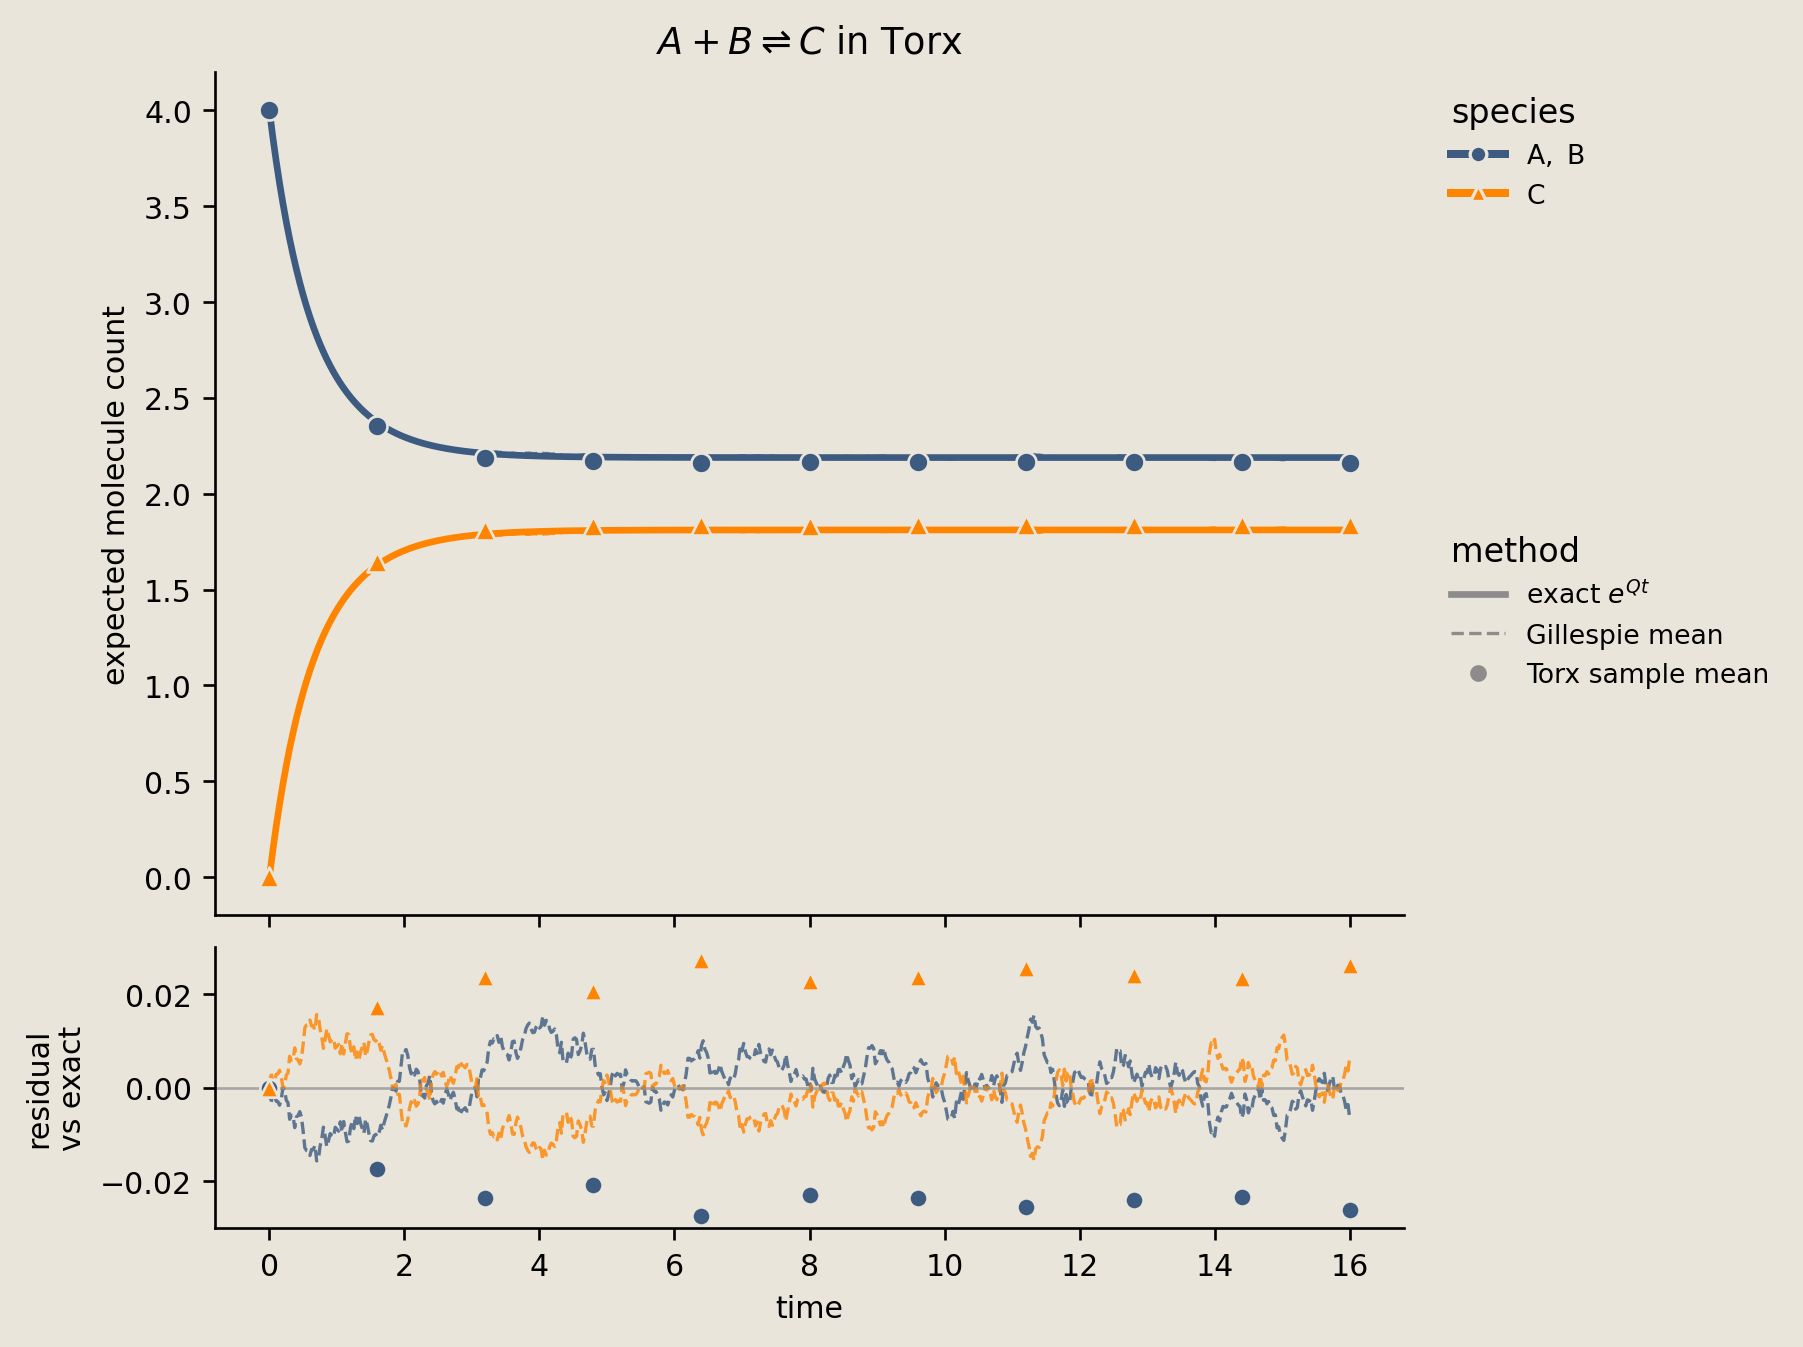

In [27]:
series_b = [
    (r"$\mathrm{A},\ \mathrm{B}$", A, EXACT_COLOR, "o"),
    (r"$\mathrm{C}$", C, TORX_COLOR, "^"),
]
fig = plot_species_dynamics(
    r"$A + B \rightleftharpoons C$ in Torx",
    times_b, ref_counts_b, gil_counts_b, snapshot_times_b, torx_counts_b, series_b,
)
savefig(fig, "05_binding_equilibrium")


The counts do level off, well short of completion, which is the visible difference from the irreversible water reaction and the sign that this network reaches equilibrium instead of absorbing. $\mathrm{A}$ and $\mathrm{B}$ start equal and stay equal because $n_{\mathrm{A}} - n_{\mathrm{B}} = 0$ along every reachable configuration, so they trace one curve. Their means settle near $2.19$ while the mean of $\mathrm{C}$ settles near $1.81$. The residual panel again makes the small Torx and Gillespie deviations from the exact curves visible. One caution about reading those plateaus: the relation that actually holds at stochastic equilibrium is the ensemble identity $k_f\,\mathbb{E}[n_{\mathrm{A}}n_{\mathrm{B}}] = k_r\,\mathbb{E}[n_{\mathrm{C}}]$, which isn't the same as substituting the mean counts into the rate law.


The same faithfulness question applies to the binding network, with one addition, because a reversible network has something to conserve and something to balance.

Binding leaves $n_{\mathrm{A}} + n_{\mathrm{C}}$ and $n_{\mathrm{B}} + n_{\mathrm{C}}$ unchanged, so we recompute both totals at the endpoints of every edge and require them to match, which is the analogue of the atom balance from the water network.

We then repeat the two method comparisons, requiring the largest deviation of the Torx snapshot counts and of the Gillespie means from the exact matrix exponential to stay below $0.05$ at the sampled times.

Finally we test equilibrium directly, evaluating $k_f\,\mathbb{E}[n_{\mathrm{A}}n_{\mathrm{B}}]$ and $k_r\,\mathbb{E}[n_{\mathrm{C}}]$ under the exact distribution at the final time and requiring their difference to fall below $10^{-6}$, so that a pass confirms the plateau in the plot is a genuine flux balance rather than a slow transient.


In [28]:
cons = {"A+C": np.array([1, 0, 1]), "B+C": np.array([0, 1, 1])}
for i, j, _ in edges_b:
    for w in cons.values():
        assert w @ np.array(configs_b[i]) == w @ np.array(configs_b[j])

torx_vs_exact_b = float(np.max(np.abs(torx_counts_b - ref_counts_b[snapshot_reps_b])))
gil_vs_exact_b = float(np.max(np.abs(gil_counts_b[snapshot_reps_b] - ref_counts_b[snapshot_reps_b])))
config_array_b = np.asarray(configs_b)
forward_flux_b = float(kf * np.sum(ref_dist_b[-1] * config_array_b[:, A] * config_array_b[:, B]))
reverse_flux_b = float(kr * np.sum(ref_dist_b[-1] * config_array_b[:, C]))
flux_residual_b = abs(forward_flux_b - reverse_flux_b)

assert torx_vs_exact_b < 0.05 and gil_vs_exact_b < 0.05
assert flux_residual_b < 1e-6
print("conservation (A+C, B+C)        : OK")
print(f"max |Torx - exact|             : {torx_vs_exact_b:.4f}  (< 0.05)")
print(f"max |Gillespie - exact|        : {gil_vs_exact_b:.4f}  (< 0.05)")
print(f"|kf E[n_A n_B] - kr E[n_C]|   : {flux_residual_b:.2e}  (< 1e-6)")
print("all checks passed")


conservation (A+C, B+C)        : OK
max |Torx - exact|             : 0.0274  (< 0.05)
max |Gillespie - exact|        : 0.0105  (< 0.05)
|kf E[n_A n_B] - kr E[n_C]|   : 1.64e-09  (< 1e-6)
all checks passed


## The cost: configuration count

Both networks above were small. What decides whether this encoding scales is how fast the configuration count grows when they aren't, because Torx spends one pbit per reachable configuration and the circuit width follows that count rather than the number of species. For the one-way water family measured below there is a single reaction extent to vary, so the count grows linearly. For the particular water-plus-ammonia family there are two independently variable extents, so it grows quadratically. Other networks scale differently, since conservation laws and feasibility constraints decide how much of the count lattice is reachable at all.


We count the reachable configurations as the molecule budget grows, first for the single water reaction and then for two reactions that share a species, which is the comparison that separates one free extent from two.


In [29]:
def n_reachable(initial, reaction_list):
    rs = [({a: b for a, b in r[0]}, {a: b for a, b in r[1]}) for r in reaction_list]
    seen, frontier = {initial}, [initial]
    while frontier:
        s = frontier.pop()
        for reac, prod in rs:
            if all(s[k] >= nu for k, nu in reac.items()):
                nxt = list(s)
                for k, nu in reac.items(): nxt[k] -= nu
                for k, nu in prod.items(): nxt[k] += nu
                nxt = tuple(nxt)
                if nxt not in seen: seen.add(nxt); frontier.append(nxt)
    return len(seen)




In [30]:
water = ((( 0, 2), (1, 1)), ((2, 2),))                 # 2 H2 + O2 -> 2 H2O
ammonia = ((( 0, 3), (3, 1)), ((4, 2),))               # N2 + 3 H2 -> 2 NH3
print("one reaction (water), scaling up:")
for k in (2, 4, 8, 16, 32):
    print(f"  H2={2*k:>3}, O2={k:>2}  ->  {n_reachable((2*k, k, 0), [water]):>4} configs")
print("two coupled reactions (water + ammonia, shared H2):")
for k in (2, 4, 8, 16, 32):
    print(f"  H2={6*k:>3}, O2={k:>2}, N2={k:>2}  ->  {n_reachable((6*k, k, 0, k, 0), [water, ammonia]):>4} configs")

one reaction (water), scaling up:
  H2=  4, O2= 2  ->     3 configs
  H2=  8, O2= 4  ->     5 configs
  H2= 16, O2= 8  ->     9 configs
  H2= 32, O2=16  ->    17 configs
  H2= 64, O2=32  ->    33 configs
two coupled reactions (water + ammonia, shared H2):
  H2= 12, O2= 2, N2= 2  ->     9 configs
  H2= 24, O2= 4, N2= 4  ->    25 configs
  H2= 48, O2= 8, N2= 8  ->    81 configs
  H2= 96, O2=16, N2=16  ->   289 configs
  H2=192, O2=32, N2=32  ->  1089 configs


Coupling the second reaction through shared $\mathrm{H_2}$ in this constructed family produces a square grid of reaction extents, which is why the two columns differ by a power rather than by a factor. At the largest budget the water reaction reaches 33 configurations, while this joint network reaches $33^2 = 1089$.


## Conclusion

We turned two nonlinear mass-action networks into single-token graph walks by enumerating their reachable configurations, which moves the nonlinearity out of the dynamics and into the edge rates. Torx then applies the per-edge `PJUMP` kernels as an operator-splitting approximation, while $e^{Qt}$ on the same generator supplies the exact global CTMC reference, so the residual panels separate two distinct disagreements: the combined split-step and sampling error carried by the Torx markers, and the sampling error carried by the Gillespie means.

The price of the one-hot encoding is the reachable configuration count, which grew linearly for the one-reaction family and quadratically for the two-reaction family measured above. Richer encodings become preferable once a network's reachable set grows large. In the linear, single-token corner of this construction the circuit is a directed [graph random walk](02_random_walks_on_graphs.ipynb) with one walker.

See also:

- [`02_random_walks_on_graphs.ipynb`](02_random_walks_on_graphs.ipynb), the single-token graph-transport corner of this construction.
- [`04_execution_interface_readouts.ipynb`](04_execution_interface_readouts.ipynb), how `BranchingSimulator` estimates expectations from bitstrings.


## References

1. Gillespie, D.T. 1977. [*Exact stochastic simulation of coupled chemical reactions*](https://doi.org/10.1021/j100540a008). J. Phys. Chem. 81(25), 2340-2361. The stochastic simulation algorithm used as a sampling reference above.
